In [ ]:
###-RUSHDA QURESHI-
####--2503951-MSBAWE2

In [1]:
###-1. Data Loading and Initial Inspection
import pandas as pd

In [2]:
# Load both datasets (note the ';' delimiter)
red_wine = pd.read_csv('winequality-red.csv', sep=';')

In [3]:
white_wine = pd.read_csv('winequality-white.csv', sep=';')

In [4]:
# Add a 'type' column to keep track of the wine variety
red_wine['type'] = 'red'
white_wine['type'] = 'white'

In [5]:
# Combine into one dataframe
df = pd.concat([red_wine, white_wine], ignore_index=True)

In [6]:
# Save the combined dataset
df.to_csv('combined_wine_quality.csv', index=False)

In [7]:
print("Files combined successfully. Shape:", df.shape)

Files combined successfully. Shape: (6497, 13)


In [8]:
###-2. Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt

In [9]:
import seaborn as sns

In [10]:
# A. Descriptive Statistics
print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.009000             1.000000         

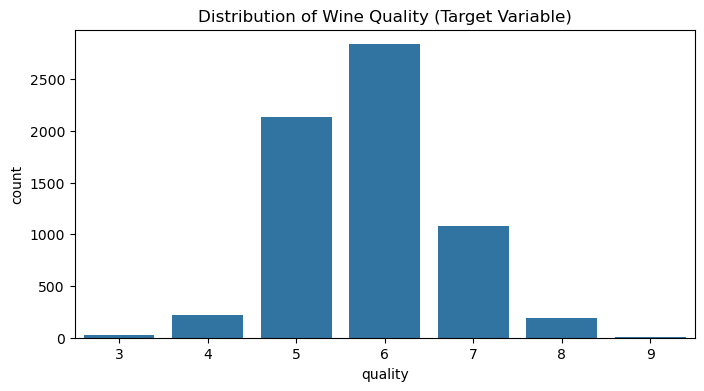

In [11]:
# B. Class Imbalance (Check distribution of 'quality')
plt.figure(figsize=(8, 4))
sns.countplot(x='quality', data=df)
plt.title('Distribution of Wine Quality (Target Variable)')
plt.savefig('bar_chart_quality.png')

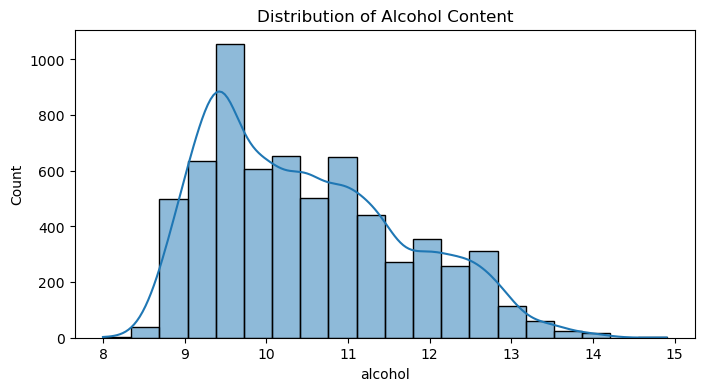

In [12]:
# C. Histograms (Distribution of a feature)
plt.figure(figsize=(8, 4))
sns.histplot(df['alcohol'], kde=True, bins=20)
plt.title('Distribution of Alcohol Content')
plt.savefig('histogram_alcohol.png')

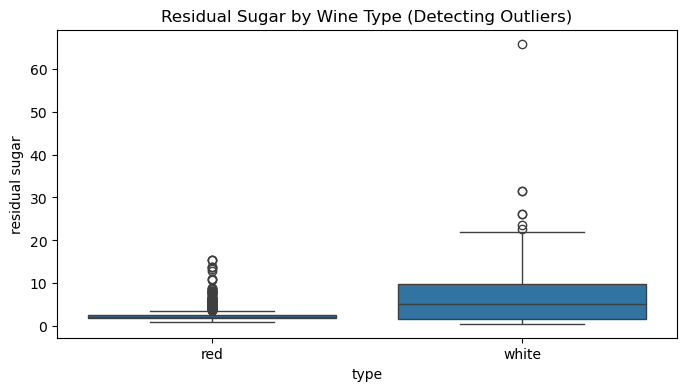

In [13]:
# D. Box Plots (Identify Outliers)
plt.figure(figsize=(8, 4))
sns.boxplot(x='type', y='residual sugar', data=df)
plt.title('Residual Sugar by Wine Type (Detecting Outliers)')
plt.savefig('boxplot_sugar.png')

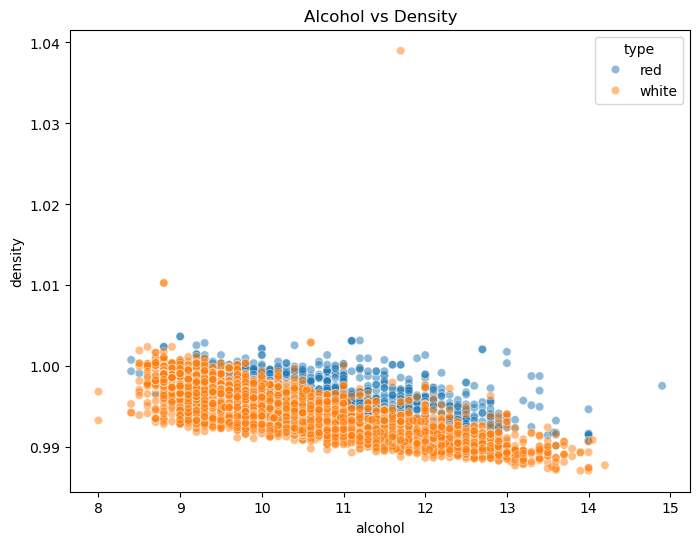

In [14]:
# E. Scatter Plot (Relationships between features)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='alcohol', y='density', hue='type', data=df, alpha=0.5)
plt.title('Alcohol vs Density')
plt.savefig('scatter_alcohol_density.png')

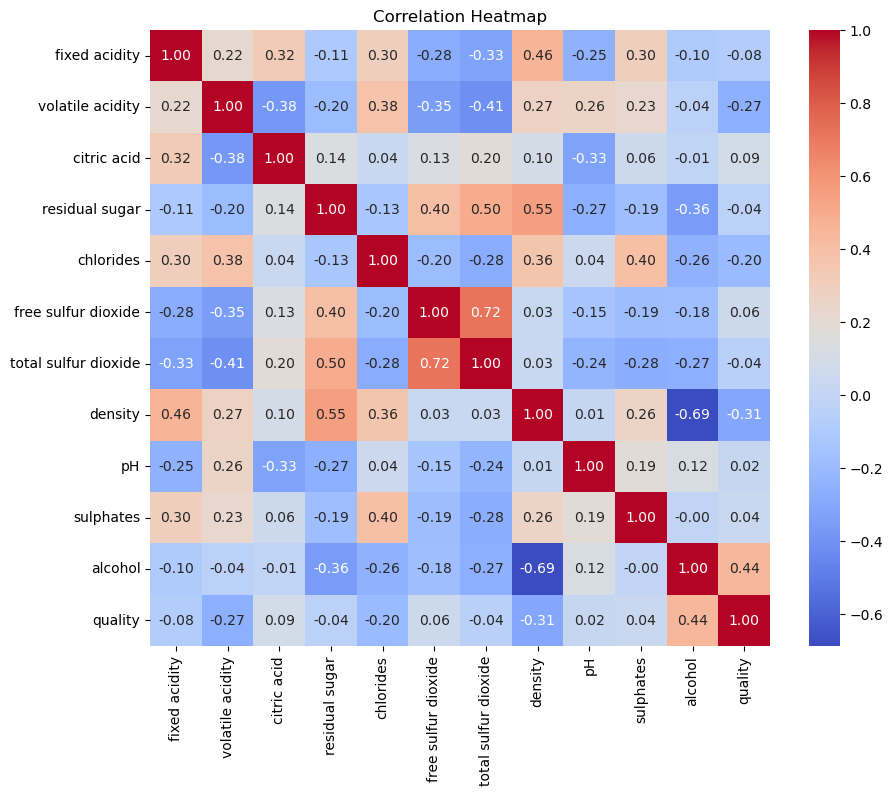

In [15]:
# F. Correlation Heatmap
plt.figure(figsize=(10, 8))
# Use only numeric columns for correlation
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('heatmap_wine.png')

In [16]:
###- 3. Feature Engineering, Scaling, and Splitting
from sklearn.model_selection import train_test_split

In [17]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [19]:
# 1. Encoding 'type' (red=0, white=1)
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

In [20]:
# 2. Define Features (X) and Target (y)
X = df.drop('quality', axis=1)
y = df['quality']

In [21]:
# 3. Stratified Train/Test Split
# Ensuring 'quality' classes are distributed evenly
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [22]:
# 4. Scaling Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
##-4. Baseline Modeling (Linear and Logistic Regression)
from sklearn.linear_model import LinearRegression, LogisticRegression

In [24]:
from sklearn.model_selection import cross_val_score

In [25]:
from sklearn.metrics import mean_squared_error, classification_report

In [27]:
###- A. Baseline Linear Regression (Predicting quality as a continuous score)
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
lin_preds = lin_model.predict(X_test_scaled)
print(f"Linear Regression MSE: {mean_squared_error(y_test, lin_preds):.4f}")

Linear Regression MSE: 0.5300


In [28]:
# B. Baseline Logistic Regression (Predicting quality as categories)
# Max_iter is increased to ensure convergence
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [29]:
# C. Cross-Validation for Logistic Regression
cv_scores = cross_val_score(log_model, X_train_scaled, y_train, cv=5)
print(f"Logistic Regression CV Accuracy: {cv_scores.mean():.4f}")

C:\Users\rushd\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Logistic Regression CV Accuracy: 0.5440


In [30]:
# D. Final Report
log_preds = log_model.predict(X_test_scaled)
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, log_preds, zero_division=0))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       1.00      0.05      0.09        43
           5       0.58      0.54      0.56       428
           6       0.52      0.72      0.60       567
           7       0.54      0.29      0.38       216
           8       0.00      0.00      0.00        39
           9       0.00      0.00      0.00         1

    accuracy                           0.54      1300
   macro avg       0.38      0.23      0.23      1300
weighted avg       0.54      0.54      0.51      1300

